# Experiments for *Geometric structure of shallow neural networks and constructive $L^2$ cost minimization*, T. Chen and P. M. Ewald.

## (Run first) Setup

Importing dependencies.

In [1]:
import math
import os

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

Class and function definitions.

In [2]:
# =========================
# 1. Data generation (GMM)
# =========================

def generate_gmm(M, Q, n, cluster_std=0.5, device="cpu", seed=None):
    """
    Generate a Gaussian mixture model in R^M with Q classes and n points per class.
    - Means are linearly independent and randomly distributed (orthonormal columns).
    - All Gaussians have isotropic covariance cluster_std^2 * I_M.

    Returns:
        means:        tensor of shape (M, Q), columns are class means mu_i
        data_by_cls:  tensor of shape (Q, n, M), data_by_cls[i] are points of class i
        X:            tensor of shape (Q*n, M), all data stacked
        Y:            tensor of shape (Q*n, Q), one-hot labels
    """
    if Q > M:
        raise ValueError("This code assumes Q <= M so that class means can be linearly independent.")

    if seed is not None:
        torch.manual_seed(seed)

    # Generate orthonormal columns (linearly independent) in R^M
    A = torch.randn(M, Q, device=device)
    Qmat, _ = torch.linalg.qr(A)      # (M, Q), orthonormal columns
    means = Qmat                      # use unit vectors as random means

    # Generate data per class
    data_by_cls = torch.zeros(Q, n, M, device=device)
    one_hot_templates = []
    for i in range(Q):
        noise = cluster_std * torch.randn(n, M, device=device)
        data_by_cls[i] = noise + means[:, i]  # broadcast over n

        one_hot = torch.zeros(Q, device=device)
        one_hot[i] = 1.0
        one_hot_templates.append(one_hot)

    # Stack into X, Y
    X = data_by_cls.reshape(Q * n, M)
    Y = torch.stack(one_hot_templates, dim=0).repeat_interleave(n, dim=0)  # (Q*n, Q)

    return means, data_by_cls, X, Y


# =========================================
# 2. Network + training with MSE (ReLU NN)
# =========================================

class SimpleReLUNet(nn.Module):
    """
    Feedforward ReLU neural network with architecture [M, M, Q].
    """
    def __init__(self, M, Q):
        super().__init__()
        self.fc1 = nn.Linear(M, M)
        self.fc2 = nn.Linear(M, Q)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


def mse_loss_per_sample(y_pred, y_true):
    """
    MSE with normalization 1/N (not 1/(NQ)):

        L = (1 / N) * sum_{i=1}^N sum_{j=1}^Q (y_pred[i,j] - y_true[i,j])^2

    Implementation: sum over classes per sample, then average over samples.
    """
    diff = y_pred - y_true           # (N, Q)
    return diff.pow(2).sum(dim=1).mean()  # (1/N) * sum_i sum_j diff^2


def train_network(
    X,
    Y,
    M,
    Q,
    max_epochs=1000,
    lr=0.05,
    momentum=0.9,
    plateau_tol=1e-4,
    plateau_patience=30,
    verbose=False,
    device="cpu",
    seed=None,
):
    """
    Train a [M, M, Q] ReLU network with MSE loss (1/N normalization) to fit (X, Y).

    Returns:
        model
        loss_history: list of training losses per epoch
        C_final: sqrt(final loss)
        C_init: sqrt(initial loss before training)
    """
    if seed is not None:
        torch.manual_seed(seed)

    X = X.to(device)
    Y = Y.to(device)

    model = SimpleReLUNet(M, Q).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    criterion = mse_loss_per_sample

    N = X.size(0)

    # Shuffle data once for training
    perm = torch.randperm(N, device=device)
    X = X[perm]
    Y = Y[perm]

    # Initial loss (before any training)
    with torch.no_grad():
        outputs0 = model(X)
        loss0 = criterion(outputs0, Y)
    loss0_val = float(loss0.item())
    C_init = math.sqrt(loss0_val)

    best_loss = loss0_val
    patience_counter = 0
    loss_history = []

    if verbose:
        print(f"Initial loss = {loss0_val:.6f}, C_init = sqrt(loss0) = {C_init:.6f}")

    for epoch in range(max_epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        optimizer.step()

        loss_val = float(loss.item())
        loss_history.append(loss_val)

        # Plateau detection based on best loss so far
        if loss_val < best_loss - plateau_tol * best_loss:
            best_loss = loss_val
            patience_counter = 0
        else:
            patience_counter += 1

        if verbose and (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:4d} | loss = {loss_val:.6f}")

        if patience_counter >= plateau_patience:
            if verbose:
                print(f"Stopping early at epoch {epoch+1}, loss plateaued.")
            break

    final_loss = loss_history[-1] if loss_history else loss0_val
    C_final = math.sqrt(final_loss)

    if verbose:
        print(f"Final loss = {final_loss:.6f}, C_final = sqrt(loss) = {C_final:.6f}")

    return model, loss_history, C_final, C_init


# ================================================
# 3. X0bar, DeltaX0 and Bound computation
# ================================================

def compute_bound(means, data_by_cls):
    """
    Compute:
    - X0bar: matrix whose columns are the Q class means (shape (M, Q))
    - DeltaX0_i: for class i, matrix whose columns are (x - mu_i) for each data point
                 in class i (shape (M, n))
    - DeltaX0: concatenation [DeltaX0_1, ..., DeltaX0_Q] along columns (shape (M, Q*n))

    Let N = Q * n. Then:

        A = (X0bar)^+ @ DeltaX0
        Bound = (1 / sqrt(N)) * ||A||_F

    Returns:
        Bound (float)
    """
    # means: (M, Q)
    # data_by_cls: (Q, n, M)
    device = means.device
    M_dim, Q = means.shape
    Q_data, n, M_check = data_by_cls.shape
    assert Q_data == Q and M_check == M_dim, "Dimension mismatch in compute_bound."

    X0bar = means  # (M, Q)

    # Construct DeltaX0
    delta_blocks = []
    for i in range(Q):
        # data_by_cls[i]: (n, M)
        diffs = data_by_cls[i] - means[:, i].view(1, M_dim)  # (n, M)
        diffs_T = diffs.T  # (M, n), columns are (x_k - mu_i)
        delta_blocks.append(diffs_T)

    DeltaX0 = torch.cat(delta_blocks, dim=1)  # (M, Q*n)

    # Pseudoinverse of X0bar (M, Q) -> (Q, M)
    X0bar_pinv = torch.linalg.pinv(X0bar)  # (Q, M)

    # Product and Frobenius norm
    A = X0bar_pinv @ DeltaX0  # (Q, Q*n)
    frob_norm = torch.linalg.norm(A, ord="fro").item()

    N = Q * n
    Bound = (1.0 / math.sqrt(N)) * frob_norm
    return Bound


# =====================================================
# 4. Experiment wrapper: multiple inits, loop over Q
# =====================================================

def run_experiment_for_M_n(
    M,
    n,
    Q_values,
    num_inits=20,
    cluster_std=0.5,
    max_epochs=1000,
    lr=0.05,
    momentum=0.9,
    plateau_tol=1e-4,
    plateau_patience=30,
    device=None,
    verbose=False,
):
    """
    For fixed M and n, loop over Q in Q_values.

    For each Q:
      1) Generate a GMM dataset once.
      2) Compute Bound for that dataset.
      3) Run num_inits different random initializations of the [M, M, Q] network,
         record C_init and C_final for each run.
      4) Return arrays of:
           bounds, C_init_means, C_init_stds, C_final_means, C_final_stds.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    bounds = []
    C_init_means = []
    C_init_stds = []
    C_final_means = []
    C_final_stds = []

    for Q in Q_values:
        print(f"\n=== Running experiments for Q = {Q} ===")
        means, data_by_cls, X, Y = generate_gmm(
            M=M, Q=Q, n=n, cluster_std=cluster_std, device=device, seed=12345
        )

        Bound = compute_bound(means, data_by_cls)
        bounds.append(Bound)

        C_init_list = []
        C_final_list = []
        for init_idx in range(num_inits):
            seed = 1000 + init_idx
            _, _, C_final, C_init = train_network(
                X,
                Y,
                M,
                Q,
                max_epochs=max_epochs,
                lr=lr,
                momentum=momentum,
                plateau_tol=plateau_tol,
                plateau_patience=plateau_patience,
                verbose=False,
                device=device,
                seed=seed,
            )
            C_init_list.append(C_init)
            C_final_list.append(C_final)

        C_init_vals = np.array(C_init_list, dtype=np.float64)
        C_final_vals = np.array(C_final_list, dtype=np.float64)

        mean_C_init = C_init_vals.mean()
        std_C_init = C_init_vals.std(ddof=1) if len(C_init_vals) > 1 else 0.0
        mean_C_final = C_final_vals.mean()
        std_C_final = C_final_vals.std(ddof=1) if len(C_final_vals) > 1 else 0.0

        C_init_means.append(mean_C_init)
        C_init_stds.append(std_C_init)
        C_final_means.append(mean_C_final)
        C_final_stds.append(std_C_final)

        print(
            f"Q = {Q}: Bound = {Bound:.6f},  "
            f"mean(C_init) = {mean_C_init:.6f}, std(C_init) = {std_C_init:.6f},  "
            f"mean(C_final) = {mean_C_final:.6f}, std(C_final) = {std_C_final:.6f}"
        )

    return (
        np.array(bounds),
        np.array(C_init_means),
        np.array(C_init_stds),
        np.array(C_final_means),
        np.array(C_final_stds),
    )

Plotting function.

In [3]:
def plot_results(M, n, cluster_std, Q_values, bounds, C_init_means, C_init_stds, C_final_means, C_final_stds):
    """
    Plot mean C_init and C_final with error bars vs Q, and Bound vs Q on the same plot.
    """
    Q_axis = np.array(Q_values, dtype=np.int32)

    color_init = "#005f86"
    color_final = "#bf5700"
    color_bound = "#579D42"


    plt.figure(figsize=(7, 4))

    # Initial C
    plt.errorbar(
        Q_axis,
        C_init_means,
        yerr=C_init_stds,
        fmt="o-",
        capsize=4,
        label="C_init",
        color=color_init,
    )

    # Final C
    plt.errorbar(
        Q_axis,
        C_final_means,
        yerr=C_final_stds,
        fmt="o--",
        capsize=4,
        label="C_final",
        color=color_final,
    )

    # Bound
    plt.plot(
        Q_axis,
        bounds,
        "s-.",
        label="Bound",
        color=color_bound,
    )

    plt.xlabel("Number of classes Q")
    plt.ylabel("Value")
    plt.title(f"Comparison of bound and cost (cluster std={cluster_std}, M={M})")
    plt.grid(True)
    plt.legend()

    # Uncomment to save instead of (or in addition to) showing
    os.makedirs("plots", exist_ok=True)
    filename = f"plots/std{cluster_std}_M{M}_n{n}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

## Experiments

Experiment parameters:
- M = input dimension
- n = number of points per class
- Q_values  = list of number of classes to test
- cluster_std = standard deviation of the clusters (gaussian mixture model)
- num_inits = number of random initializations to average over, per Q value

Networks are trained with SGD with the following hyperparameters being adjustable:
- max_epochs = maximum number of epochs 
- lr = learning rate
- momentum 
- plateau_tol 
- plateau_patience


=== Running experiments for Q = 4 ===
Q = 4: Bound = 0.369157,  mean(C_init) = 1.131323, std(C_init) = 0.159902,  mean(C_final) = 0.361447, std(C_final) = 0.211027

=== Running experiments for Q = 3 ===
Q = 3: Bound = 0.356829,  mean(C_init) = 1.167314, std(C_init) = 0.154160,  mean(C_final) = 0.239968, std(C_final) = 0.128257

=== Running experiments for Q = 2 ===
Q = 2: Bound = 0.282703,  mean(C_init) = 1.061712, std(C_init) = 0.194318,  mean(C_final) = 0.179298, std(C_final) = 0.192021

Summary:
  Q= 4 | Bound=0.369157 | mean(C_init)=1.131323, std(C_init)=0.159902 | mean(C_final)=0.361447, std(C_final)=0.211027
  Q= 3 | Bound=0.356829 | mean(C_init)=1.167314, std(C_init)=0.154160 | mean(C_final)=0.239968, std(C_final)=0.128257
  Q= 2 | Bound=0.282703 | mean(C_init)=1.061712, std(C_init)=0.194318 | mean(C_final)=0.179298, std(C_final)=0.192021


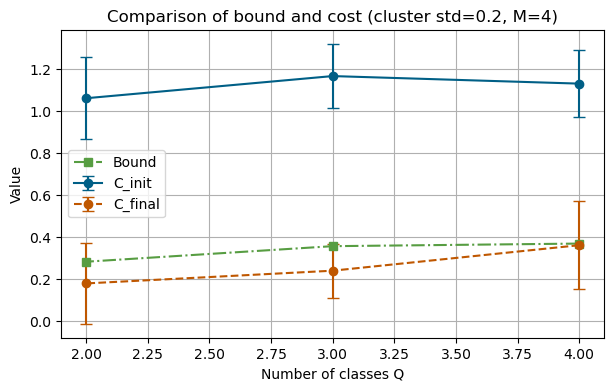

In [11]:
# =============================
# 5. Main test
# =============================

if __name__ == "__main__":
    M = 4
    n = 10
    Q_values = [4,3,2]

    # Default hyperparameters; adjust as desired
    num_inits = 10
    cluster_std = 0.2
    max_epochs = 1000
    lr = 0.05
    momentum = 0.9
    plateau_tol = 1e-4
    plateau_patience = 30

    (
        bounds,
        C_init_means,
        C_init_stds,
        C_final_means,
        C_final_stds,
    ) = run_experiment_for_M_n(
        M=M,
        n=n,
        Q_values=Q_values,
        num_inits=num_inits,
        cluster_std=cluster_std,
        max_epochs=max_epochs,
        lr=lr,
        momentum=momentum,
        plateau_tol=plateau_tol,
        plateau_patience=plateau_patience,
        device=None,
        verbose=False,
    )

    print("\nSummary:")
    for Q, B, c0m, c0s, cfm, cfs in zip(
        Q_values, bounds, C_init_means, C_init_stds, C_final_means, C_final_stds
    ):
        print(
            f"  Q={Q:2d} | Bound={B:.6f} | "
            f"mean(C_init)={c0m:.6f}, std(C_init)={c0s:.6f} | "
            f"mean(C_final)={cfm:.6f}, std(C_final)={cfs:.6f}"
        )

    plot_results(M, n, cluster_std, Q_values, bounds, C_init_means, C_init_stds, C_final_means, C_final_stds)
